# Experiment 2

In [1]:
#step1: Install Required Packages
!pip install opencv-python pycocotools tqdm matplotlib
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/8c/4541z2b93d74vbzt0pxzpz_m0000gn/T/pip-req-build-w4coyzp7
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/8c/4541z2b93d74vbzt0pxzpz_m0000gn/T/pip-req-build-w4coyzp7
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [2]:
#step1.1
import os

# Define your dynamic path variables
SHAPES_FOLDER = "shapes"        # folder containing run.py, visualize.py
DATASET_NAME  = "shapes_dataset" # subfolder name for your dataset

# 1) Set your HOME path
os.environ["HOME"] = "/Users/ma/Documents/samThesis/segment-anything/notebooks/S1-COCO-v1"

# 2) Print to confirm
print("HOME is now:", os.environ["HOME"])

HOME is now: /Users/ma/Documents/samThesis/segment-anything/notebooks/S1-COCO-v1


In [3]:
#rm -rf ./shapes_dataset

In [4]:
#step2: Generate the Shapes Dataset
import subprocess
import os

# Modify these as you like
NUM_IMAGES = 20
IMG_WIDTH = 80
IMG_HEIGHT = 80
SAVE_DIR = f"./{DATASET_NAME}"   # We'll store the dataset in "shapes_dataset" (relative to SHAPES_FOLDER)

# Make sure the directory exists
os.makedirs(SAVE_DIR, exist_ok=True)

command = [
    "python", "run.py",
    "--save_dir", SAVE_DIR,      # e.g. "./shapes_dataset"
    "--task_type", "detection",
    "--num_images", str(NUM_IMAGES),
    "--image_size", str(IMG_WIDTH), str(IMG_HEIGHT),
    "--shapes", "circle", "rect",
    "--shape_color", "blue",     # Force shapes to be blue
    "--shuffle_color", "False"   # Turn off color shuffling
]

# We'll run this script from inside SHAPES_FOLDER
result = subprocess.run(command, cwd=SHAPES_FOLDER, capture_output=True, text=True)

print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)
print("Dataset generated at:", SAVE_DIR)
print("Check subfolders like 'images' and 'labels_json' within it...")

STDOUT: [DEBUG] Dynamic shape attributes:
  rect size = [8, 8]
  circle radius = 6
[DEBUG] run.py arguments:
  save_dir = ./shapes_dataset
  image_size = [80, 80]
  num_images = 20
  shapes = ['rect', 'circle']
  shape_color = blue , shuffle_color = True
  task_type = detection
[DEBUG] detection_gen: Saving images to ./shapes_dataset/images
[DEBUG] detection_gen: Saving labels to ./shapes_dataset/labels_json
[DEBUG] Image 0: Generating 4 shapes.
[DEBUG] rect at (x=34, y=11) -> bbox={'object': 'rect', 'x': 34, 'y': 11, 'w': 8, 'h': 8}
[DEBUG] circle at (x=16, y=67) -> bbox={'object': 'circle', 'x': 10, 'y': 61, 'w': 12, 'h': 12}
[DEBUG] circle at (x=48, y=42) -> bbox={'object': 'circle', 'x': 42, 'y': 36, 'w': 12, 'h': 12}
[DEBUG] rect at (x=34, y=19) -> bbox={'object': 'rect', 'x': 34, 'y': 19, 'w': 8, 'h': 8}
[DEBUG] Saving image: ./shapes_dataset/images/shapes_0.png
[DEBUG] Saving JSON: ./shapes_dataset/labels_json/shapes_0.json
[DEBUG] Image 1: Generating 3 shapes.
[DEBUG] circle at

In [5]:
#check dataset folder content
!ls -R shapes/shapes_dataset

coco_annotations.json            images
coco_annotations_with_masks.json labels_json

shapes/shapes_dataset/images:
shapes_0.png  shapes_12.png shapes_16.png shapes_2.png  shapes_6.png
shapes_1.png  shapes_13.png shapes_17.png shapes_3.png  shapes_7.png
shapes_10.png shapes_14.png shapes_18.png shapes_4.png  shapes_8.png
shapes_11.png shapes_15.png shapes_19.png shapes_5.png  shapes_9.png

shapes/shapes_dataset/labels_json:
shapes_0.json  shapes_12.json shapes_16.json shapes_2.json  shapes_6.json
shapes_1.json  shapes_13.json shapes_17.json shapes_3.json  shapes_7.json
shapes_10.json shapes_14.json shapes_18.json shapes_4.json  shapes_8.json
shapes_11.json shapes_15.json shapes_19.json shapes_5.json  shapes_9.json


In [6]:
#step3: Visualize Bounding Boxes With visualize.py
import subprocess

# The dataset was generated at "shapes/shapes_dataset"
dataset_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME)

command = [
    "python", os.path.join(SHAPES_FOLDER, "visualize.py"),  
    "--dataset_dir", dataset_dir
]
result = subprocess.run(command, capture_output=True, text=True)
print("STDOUT:", result.stdout)
print("STDERR:", result.stderr)

STDOUT: Image file: shapes_0.png
Label file: shapes_0.json
Figure(80x80)
Image file: shapes_1.png
Label file: shapes_1.json
Figure(80x80)
Image file: shapes_10.png
Label file: shapes_10.json
Figure(80x80)
Image file: shapes_11.png
Label file: shapes_11.json
Figure(80x80)
Image file: shapes_12.png
Label file: shapes_12.json
Figure(80x80)
Image file: shapes_13.png
Label file: shapes_13.json
Figure(80x80)
Image file: shapes_14.png
Label file: shapes_14.json
Figure(80x80)
Image file: shapes_15.png
Label file: shapes_15.json
Figure(80x80)
Image file: shapes_16.png
Label file: shapes_16.json
Figure(80x80)
Image file: shapes_17.png
Label file: shapes_17.json
Figure(80x80)
Image file: shapes_18.png
Label file: shapes_18.json
Figure(80x80)
Image file: shapes_19.png
Label file: shapes_19.json
Figure(80x80)
Image file: shapes_2.png
Label file: shapes_2.json
Figure(80x80)
Image file: shapes_3.png
Label file: shapes_3.json
Figure(80x80)
Image file: shapes_4.png
Label file: shapes_4.json
Figure(80x8

Image: shapes_0.png
Label: shapes_0.json


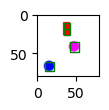

Image: shapes_1.png
Label: shapes_1.json


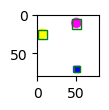

Image: shapes_10.png
Label: shapes_10.json


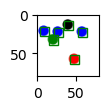

Image: shapes_11.png
Label: shapes_11.json


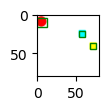

Image: shapes_12.png
Label: shapes_12.json


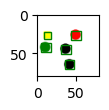

Image: shapes_13.png
Label: shapes_13.json


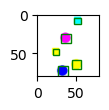

Image: shapes_14.png
Label: shapes_14.json


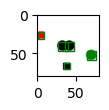

Image: shapes_15.png
Label: shapes_15.json


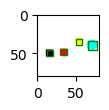

Image: shapes_16.png
Label: shapes_16.json


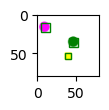

Image: shapes_17.png
Label: shapes_17.json


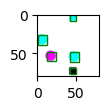

Image: shapes_18.png
Label: shapes_18.json


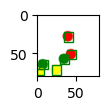

Image: shapes_19.png
Label: shapes_19.json


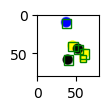

Image: shapes_2.png
Label: shapes_2.json


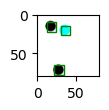

Image: shapes_3.png
Label: shapes_3.json


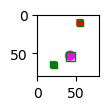

Image: shapes_4.png
Label: shapes_4.json


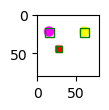

Image: shapes_5.png
Label: shapes_5.json


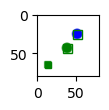

Image: shapes_6.png
Label: shapes_6.json


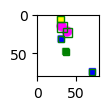

Image: shapes_7.png
Label: shapes_7.json


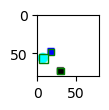

Image: shapes_8.png
Label: shapes_8.json


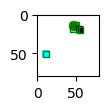

Image: shapes_9.png
Label: shapes_9.json


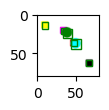

In [7]:
#step3.1: visualization for step 3
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import json
import os

def json_listing(json_data):
    label = []
    for region in json_data:
        label.append([region['x'], region['y'], region['w'], region['h']])
    return label

def bbox_plot(img, boxes):
    # Get image shape
    height, width = img.shape[0], img.shape[1]

    fig, ax = plt.subplots(figsize=(width/100, height/100))
    ax.set_xlim([0, width])
    ax.set_ylim([0, height])
    plt.gca().invert_yaxis()
    ax.imshow(img)

    for box in boxes:
        x, y, w, h = box
        rect = plt.Rectangle(
            (x, y), w, h,
            linewidth=1, edgecolor='g',
            facecolor="none"
        )
        ax.add_patch(rect)

    plt.show()

def bounding_boxes(dataset_dir):
    images_dir = os.path.join(dataset_dir, "images")
    labels_dir = os.path.join(dataset_dir, "labels_json")
    
    img_list = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    lab_list = sorted([f for f in os.listdir(labels_dir) if f.endswith(".json")])
    
    for img_file, lab_file in zip(img_list, lab_list):
        img_path = os.path.join(images_dir, img_file)
        lab_path = os.path.join(labels_dir, lab_file)
        
        img = plt.imread(img_path)
        print("Image:", img_file)
        print("Label:", lab_file)
        with open(lab_path, "r") as jf:
            box_data = json.load(jf)
            boxes = json_listing(box_data)
        
        bbox_plot(img, boxes)

# Now call the function inside the notebook
inline_dataset_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME)
bounding_boxes(inline_dataset_dir)

In [8]:
#step4: Convert Labels to a Single COCO Annotations File
import os
import json
from tqdm import tqdm

def convert_to_coco(images_dir, labels_dir, output_json):
    """
    Combine each shapes_N.json bounding box file into a single COCO annotation JSON.
    """
    coco_data = {
        "images": [],
        "annotations": [],
        "categories": [
            {"id": 1, "name": "circle", "supercategory": "shape"},
            {"id": 2, "name": "rect", "supercategory": "shape"}
        ]
    }
    
    annotation_id = 1
    image_id = 1
    
    image_files = sorted([f for f in os.listdir(images_dir) if f.endswith(".png")])
    
    for img_file in tqdm(image_files):
        base_name = img_file.replace(".png", "")
        json_file = base_name + ".json"
        json_path = os.path.join(labels_dir, json_file)
        
        # Add image info
        coco_data["images"].append({
            "id": image_id,
            "file_name": img_file,
            "width": IMG_WIDTH,
            "height": IMG_HEIGHT
        })
        
        # Read bounding box info
        if os.path.exists(json_path):
            with open(json_path, "r") as f:
                bbox_data = json.load(f)
            
            for obj in bbox_data:
                shape_type = obj['object']
                category_id = 1 if shape_type == 'circle' else 2
                x, y, w, h = obj['x'], obj['y'], obj['w'], obj['h']
                
                coco_data["annotations"].append({
                    "id": annotation_id,
                    "image_id": image_id,
                    "category_id": category_id,
                    "bbox": [x, y, w, h],
                    "segmentation": [],
                    "area": w * h,
                    "iscrowd": 0
                })
                annotation_id += 1
        
        image_id += 1
    
    with open(output_json, "w") as f:
        json.dump(coco_data, f)
    print(f"COCO annotations saved to {output_json}")

images_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")
labels_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "labels_json")
output_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations.json")

convert_to_coco(images_dir, labels_dir, output_coco)

100%|█████████████████████████████████████████| 20/20 [00:00<00:00, 6241.99it/s]

COCO annotations saved to shapes/shapes_dataset/coco_annotations.json


In [9]:
# Ensure the parent directory is in the Python path.
import sys
sys.path.insert(0, "/Users/ma/Documents/samThesis/segment-anything")

import torch
from segment_anything.modeling.image_encoder import ImageEncoderViT
from segment_anything.modeling.prompt_encoder import PromptEncoder
from segment_anything.modeling.mask_decoder import MaskDecoder
from segment_anything.modeling.sam import Sam
from segment_anything import sam_model_registry, SamPredictor

# Load a classical SAM model to extract its components.
CHECKPOINT_PATH = "./weights/sam_vit_h_4b8939.pth"
sam_classical = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
sam_classical.to("cpu")  # Move to CPU for extraction if desired

# Extract the classical components.
image_encoder = sam_classical.image_encoder
prompt_encoder = sam_classical.prompt_encoder
mask_decoder = sam_classical.mask_decoder

# Now instantiate the quantum-enhanced ImageEncoderViT.
# We enable quantum processing in the transformer blocks.
quantum_image_encoder = ImageEncoderViT(
    img_size=1024,
    patch_size=16,
    in_chans=3,
    embed_dim=768,
    depth=12,
    num_heads=12,
    mlp_ratio=4.0,
    out_chans=256,
    qkv_bias=True,
    use_abs_pos=True,
    use_rel_pos=False,
    window_size=0,
    global_attn_indexes=(),
    use_quantum=True,   # Enable quantum-enhanced attention in each block.
    n_qubits=4          # Number of qubits for quantum processing.
)

# Use the original prompt_encoder and mask_decoder.
# Instantiate the SAM model with the quantum-enhanced encoder.
model = Sam(quantum_image_encoder, prompt_encoder, mask_decoder, 
            pixel_mean=[123.675, 116.28, 103.53], pixel_std=[58.395, 57.12, 57.375])
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
predictor = SamPredictor(model)
print("✅ Quantum-enhanced SAM model loaded on device:", device)

✅ Quantum-enhanced SAM model loaded on device: cpu


In [ ]:
# Step 5: IOU and dice Evaluate Segmentation using SAM
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

def compute_iou_dice(mask_gt, mask_pred):
    intersection = np.logical_and(mask_gt, mask_pred).sum()
    union = np.logical_or(mask_gt, mask_pred).sum()
    iou = intersection / union if union != 0 else 0
    dice = (2 * intersection) / (mask_gt.sum() + mask_pred.sum()) if (mask_gt.sum() + mask_pred.sum()) != 0 else 0
    return iou, dice

def generate_gt_mask(annotation, image_shape):
    mask = np.zeros(image_shape, dtype=np.uint8)
    obj = annotation['object']
    x = annotation['x']
    y = annotation['y']
    w = annotation['w']
    h = annotation['h']
    if obj == 'rect':
        mask[y:y+h, x:x+w] = 1
    elif obj == 'circle':
        r = w // 2
        cx = x + r
        cy = y + r
        Y, X = np.ogrid[:image_shape[0], :image_shape[1]]
        dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
        mask[dist <= r] = 1
    return mask

def evaluate_segmentation(image_path, annotation_path, predictor):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print("Failed to load image:", image_path)
        return None, None
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    with open(annotation_path, 'r') as f:
        annotations = json.load(f)
    iou_list = []
    dice_list = []
    for ann in annotations:
        bbox = [ann['x'], ann['y'], ann['x']+ann['w'], ann['y']+ann['h']]
        predictor.set_image(img_rgb)
        masks, scores, _ = predictor.predict(box=np.array(bbox), multimask_output=False)
        mask_pred = masks[0] if masks.ndim == 3 else masks
        mask_pred = mask_pred.astype(np.uint8)
        mask_pred = cv2.resize(mask_pred, (w, h), interpolation=cv2.INTER_NEAREST)
        mask_gt = generate_gt_mask(ann, (h, w))
        iou, dice = compute_iou_dice(mask_gt, mask_pred)
        iou_list.append(iou)
        dice_list.append(dice)
    avg_iou = np.mean(iou_list) if iou_list else 0
    avg_dice = np.mean(dice_list) if dice_list else 0
    return avg_iou, avg_dice

def evaluate_segmentation_all(predictor, dataset_images, dataset_labels):
    img_files = sorted([f for f in os.listdir(dataset_images) if f.endswith(".png")])
    lab_files = sorted([f for f in os.listdir(dataset_labels) if f.endswith(".json")])
    all_iou = []
    all_dice = []
    for img_file, lab_file in zip(img_files, lab_files):
        image_path = os.path.join(dataset_images, img_file)
        annotation_path = os.path.join(dataset_labels, lab_file)
        iou, dice = evaluate_segmentation(image_path, annotation_path, predictor)
        print(f"{img_file}: IoU={iou:.3f}, Dice={dice:.3f}")
        all_iou.append(iou)
        all_dice.append(dice)
    avg_iou = np.mean(all_iou) if all_iou else 0
    avg_dice = np.mean(all_dice) if all_dice else 0
    print(f"Average IoU: {avg_iou:.3f}, Average Dice: {avg_dice:.3f}")

# Load SAM model (if not already loaded)
#from segment_anything import sam_model_registry, SamPredictor
#import torch
#CHECKPOINT_PATH = "./weights/sam_vit_h_4b8939.pth"
#device = "cuda" if torch.cuda.is_available() else "cpu"
#sam = sam_model_registry["vit_h"](checkpoint=CHECKPOINT_PATH)
#sam.to(device)
#predictor = SamPredictor(sam)
#print("✅ SAM model loaded on device:", device)

# Update paths to reflect the actual dataset location:
# Since you ran run.py with cwd=SHAPES_FOLDER, the dataset is located at: "shapes/shapes_dataset"
SHAPES_FOLDER = "shapes"
DATASET_NAME = "shapes_dataset"
DATASET_IMAGES = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")
DATASET_LABELS = os.path.join(SHAPES_FOLDER, DATASET_NAME, "labels_json")

# Evaluate segmentation on the dataset
evaluate_segmentation_all(predictor, DATASET_IMAGES, DATASET_LABELS)


In [ ]:
#step6: Convert Binary Masks from SAM -> COCO Polygons
import cv2
import numpy as np

def mask_to_coco_poly(binary_mask):
    """
    Convert a single binary mask (H x W) into COCO polygon format.
    """
    contours, _ = cv2.findContours(binary_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for contour in contours:
        contour = contour.flatten().tolist()
        if len(contour) >= 6:
            polygons.append(contour)
    return polygons

In [ ]:
#step7: Segment with SAM Locally & Update COCO
def segment_with_local_sam(image_dir, input_coco, output_coco):
    with open(input_coco, "r") as f:
        coco_data = json.load(f)
    
    annotations_by_image = {}
    for ann in coco_data["annotations"]:
        img_id = ann["image_id"]
        annotations_by_image.setdefault(img_id, []).append(ann)
    
    for img_info in coco_data["images"]:
        image_id = img_info["id"]
        file_name = img_info["file_name"]
        width = img_info["width"]
        height = img_info["height"]
        
        full_img_path = os.path.join(image_dir, file_name)
        
        image_bgr = cv2.imread(full_img_path)
        if image_bgr is None:
            print(f"❌ Could not load image: {full_img_path}")
            continue

        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        predictor.set_image(image_rgb)

        if image_id in annotations_by_image:
            for ann in annotations_by_image[image_id]:
                x, y, w, h = ann["bbox"]
                box = np.array([x, y, x + w, y + h])
                
                masks, scores, _ = predictor.predict(box=box, multimask_output=False)

                if masks.ndim == 2:
                    bin_mask = masks
                else:
                    bin_mask = masks[0]
                
                polygons = mask_to_coco_poly(bin_mask)
                ann["segmentation"] = polygons
    
    with open(output_coco, "w") as f:
        json.dump(coco_data, f)
    print(f"✅ COCO file updated with SAM segmentation: {output_coco}")

images_dir = os.path.join(SHAPES_FOLDER, DATASET_NAME, "images")
input_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations.json")
output_coco = os.path.join(SHAPES_FOLDER, DATASET_NAME, "coco_annotations_with_masks.json")

segment_with_local_sam(images_dir, input_coco, output_coco)

In [ ]:
#step8: Visualize the New Segmentation Masks (Optional)
def visualize_sam_segmentation(image_path, polygons_list):
    import matplotlib.pyplot as plt
    import cv2
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    
    for poly in polygons_list:
        poly_np = np.array(poly).reshape((-1, 2))
        plt.fill(poly_np[:, 0], poly_np[:, 1], color='green', alpha=0.4)
    plt.axis('off')
    plt.show()

import json
with open(output_coco, 'r') as f:
    coco_data = json.load(f)

# Loop over all images
for image_info in coco_data["images"]:
    img_id = image_info["id"]
    image_path = os.path.join(images_dir, image_info["file_name"])
    
    ann_for_img = [a for a in coco_data["annotations"] if a["image_id"] == img_id]
    
    all_polys = []
    for ann in ann_for_img:
        all_polys.extend(ann.get("segmentation", []))
    
    visualize_sam_segmentation(image_path, all_polys)